# Домашняя работа №3: Variance-Preserving SDE

**ФИО:** укажите перед сдачей

## Краткий результат

- Реализована непрерывная VP-SDE и reverse-time SDE sampling методом Euler–Maruyama — не DDPM.
- Проведены 6 запусков: linear/cosine schedule × `uniform`, `α²(t)` и `σ²(t)` weighting.
- Лучший вариант: **Cosine + `α²(t)`**, symmetric Chamfer = **0.001736**.
- Акцент на малые времена `α²(t)` улучшил Chamfer относительно uniform на 52.6% для linear и на 53.6% для cosine.
- Акцент на большие времена `σ²(t)` не восстановил звезду: получились размытые облака с Chamfer 0.046–0.051.

## 1. Постановка задачи: именно VP-SDE

Используем непрерывный прямой процесс

$$d\mathbf{x} = -\frac{1}{2}\beta(t)\mathbf{x}\,dt + \sqrt{\beta(t)}\,d\mathbf{w},$$

с аналитическим marginal

$$\mathbf{x}_t = \alpha(t)\mathbf{x}_0 + \sigma(t)\boldsymbol{\varepsilon},\qquad
\sigma^2(t)=1-\alpha^2(t).$$

Модель предсказывает шум $\varepsilon_\theta(\mathbf{x}_t,t)$, поэтому score равен

$$s_\theta(\mathbf{x}_t,t)=-\frac{\varepsilon_\theta(\mathbf{x}_t,t)}{\sigma(t)}.$$

Генерация выполняется интегрированием **reverse-time SDE** методом Euler–Maruyama:

$$d\mathbf{x} = \left[f(\mathbf{x},t)-g^2(t)s_\theta(\mathbf{x},t)\right]dt + g(t)d\bar{\mathbf{w}},\qquad dt<0.$$

Это не DDPM: в коде нет дискретной цепочки $q(x_t|x_{t-1})$, произведений дискретных $\alpha_t$ или DDPM ancestral update. Есть непрерывные $f(x,t)$, $g(t)$ и численное решение reverse SDE.

Источники формул: [Song et al., Score-Based Generative Modeling through SDEs](https://arxiv.org/abs/2011.13456); cosine $\bar\alpha(t)$: [Nichol & Dhariwal, 2021](https://proceedings.mlr.press/v139/nichol21a.html).

## 2. Setup

In [1]:
from dataclasses import dataclass, field
from pathlib import Path
import gc
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.neighbors import NearestNeighbors

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()


seed_everything(42)

In [2]:
@dataclass(frozen=True)
class Config:
    learning_rate: float = 1e-3
    epochs: int = 1200
    batch_size: int = 512
    hidden_dim: int = 256
    time_dim: int = 64
    data_samples: int = 5000
    sample_count: int = 1500
    sampling_steps: int = 600
    eps: float = 1e-3
    ema_decay: float = 0.999
    seed: int = 42
    sample_seed: int = 2026
    device: str = field(default_factory=get_device)

    beta_min: float = 0.1
    beta_max: float = 20.0
    cosine_offset: float = 0.008
    cosine_t_max: float = 0.99


config = Config()
config

Config(learning_rate=0.001, epochs=1200, batch_size=512, hidden_dim=256, time_dim=64, data_samples=5000, sample_count=1500, sampling_steps=600, eps=0.001, ema_decay=0.999, seed=42, sample_seed=2026, device='mps', beta_min=0.1, beta_max=20.0, cosine_offset=0.008, cosine_t_max=0.99)

## 3. Данные: контур звезды из кода с пары

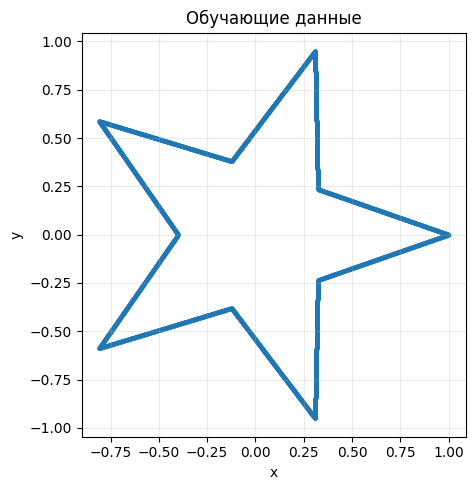

shape: (5000, 2)


In [3]:
def generate_star(
    n_spikes=5,
    inner_radius=0.4,
    outer_radius=1.0,
    n_samples=1000,
    center=(0, 0),
):
    angle_step = np.pi / n_spikes
    vertices = []
    for index in range(2 * n_spikes):
        angle = index * angle_step
        radius = outer_radius if index % 2 == 0 else inner_radius
        vertices.append([
            radius * np.cos(angle) + center[0],
            radius * np.sin(angle) + center[1],
        ])
    vertices.append(vertices[0])
    vertices = np.asarray(vertices)

    samples_per_edge = n_samples // (len(vertices) - 1)
    sampled_points = []
    for index in range(len(vertices) - 1):
        start_point = vertices[index]
        end_point = vertices[index + 1]
        interpolation = np.linspace(0, 1, samples_per_edge, endpoint=False)
        sampled_points.extend(
            (1 - weight) * start_point + weight * end_point
            for weight in interpolation
        )
    return np.asarray(sampled_points, dtype=np.float32)


star = generate_star(n_samples=config.data_samples)
fig, axis = plt.subplots(figsize=(5, 5))
axis.scatter(star[:, 0], star[:, 1], s=4, alpha=0.7)
axis.set(title='Обучающие данные', xlabel='x', ylabel='y', aspect='equal')
axis.grid(alpha=0.25)
plt.tight_layout()
display(fig)
plt.close(fig)
print('shape:', star.shape)

## 4. Linear и cosine VP-SDE schedules

Для linear schedule:

$$\beta(t)=\beta_{min}+t(\beta_{max}-\beta_{min}),$$

$$\alpha(t)=\exp\left[-\frac12\left(\beta_{min}t+\frac12(\beta_{max}-\beta_{min})t^2\right)\right].$$

Для cosine schedule задаём непрерывную $\bar\alpha(t)=\alpha^2(t)$ и получаем коэффициент SDE дифференцированием:

$$\bar\alpha(t)=\frac{\cos^2\left(\frac{t+s}{1+s}\frac\pi2\right)}{\cos^2\left(\frac{s}{1+s}\frac\pi2\right)},\qquad
\beta(t)=-\frac{d}{dt}\log\bar\alpha(t)=\frac\pi{1+s}\tan\left(\frac{t+s}{1+s}\frac\pi2\right).$$

У cosine schedule берём $T=0.99$, чтобы не вычислять сингулярность tangent при $t=1$; при этом $\alpha(T)\approx0.016$, то есть terminal distribution уже практически стандартная нормальная.

In [4]:
class LinearVPSchedule:
    name = 'Linear'

    def __init__(self, beta_min=0.1, beta_max=20.0):
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.t_max = 1.0

    def beta(self, t):
        return self.beta_min + t * (self.beta_max - self.beta_min)

    def alpha_sigma(self, t):
        integrated_beta = (
            self.beta_min * t
            + 0.5 * (self.beta_max - self.beta_min) * t.square()
        )
        alpha = torch.exp(-0.5 * integrated_beta)
        sigma = torch.sqrt((1 - alpha.square()).clamp_min(1e-12))
        return alpha, sigma


class CosineVPSchedule:
    name = 'Cosine'

    def __init__(self, offset=0.008, t_max=0.99):
        self.offset = offset
        self.t_max = t_max
        theta_zero = offset / (1 + offset) * math.pi / 2
        self.normalizer = math.cos(theta_zero) ** 2

    def _theta(self, t):
        return (t + self.offset) / (1 + self.offset) * math.pi / 2

    def beta(self, t):
        return math.pi / (1 + self.offset) * torch.tan(self._theta(t))

    def alpha_sigma(self, t):
        alpha_bar = torch.cos(self._theta(t)).square() / self.normalizer
        alpha_bar = alpha_bar.clamp(1e-12, 1.0)
        return torch.sqrt(alpha_bar), torch.sqrt((1 - alpha_bar).clamp_min(1e-12))


def make_schedule(name, config):
    if name == 'Linear':
        return LinearVPSchedule(config.beta_min, config.beta_max)
    if name == 'Cosine':
        return CosineVPSchedule(config.cosine_offset, config.cosine_t_max)
    raise ValueError(f'Unknown schedule: {name}')


schedules = {
    name: make_schedule(name, config)
    for name in ('Linear', 'Cosine')
}

with torch.inference_mode():
    for name, schedule in schedules.items():
        t = torch.tensor([[config.eps], [schedule.t_max]])
        alpha, sigma = schedule.alpha_sigma(t)
        assert torch.allclose(alpha.square() + sigma.square(), torch.ones_like(alpha), atol=1e-5)
        print(
            f'{name:6s}: alpha(eps)={alpha[0].item():.4f}, '
            f'alpha(T)={alpha[-1].item():.4f}, sigma(T)={sigma[-1].item():.4f}'
        )

Linear: alpha(eps)=0.9999, alpha(T)=0.0066, sigma(T)=1.0000
Cosine: alpha(eps)=1.0000, alpha(T)=0.0156, sigma(T)=0.9999


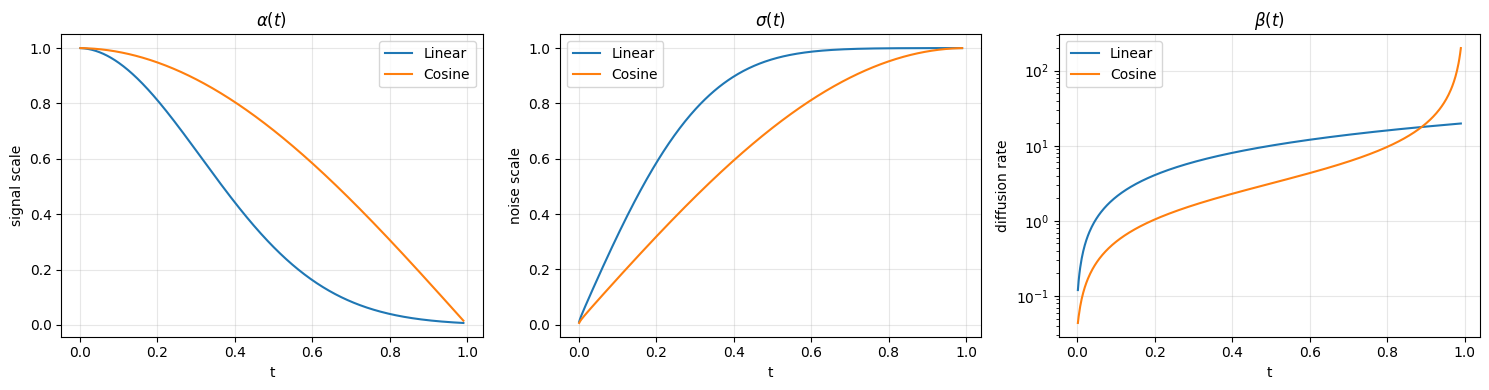

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, schedule in schedules.items():
    t = torch.linspace(config.eps, min(schedule.t_max, 0.99), 500).unsqueeze(1)
    alpha, sigma = schedule.alpha_sigma(t)
    beta = schedule.beta(t)
    axes[0].plot(t, alpha, label=name)
    axes[1].plot(t, sigma, label=name)
    axes[2].plot(t, beta, label=name)

axes[0].set(title=r'$\alpha(t)$', xlabel='t', ylabel='signal scale')
axes[1].set(title=r'$\sigma(t)$', xlabel='t', ylabel='noise scale')
axes[2].set(title=r'$\beta(t)$', xlabel='t', ylabel='diffusion rate', yscale='log')
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 5. Score model

In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        half_dimension = dimension // 2
        frequencies = torch.exp(
            -math.log(10_000)
            * torch.arange(half_dimension, dtype=torch.float32)
            / (half_dimension - 1)
        )
        self.register_buffer('frequencies', frequencies)

    def forward(self, t):
        arguments = 2 * math.pi * t * self.frequencies.unsqueeze(0)
        return torch.cat([arguments.sin(), arguments.cos()], dim=1)


class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(config.time_dim),
            nn.Linear(config.time_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
        )
        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2),
        )

    def forward(self, x, t):
        time_features = self.time_embed(t)
        return self.net(torch.cat([x, time_features], dim=1))


check_model = ScoreModel(config)
with torch.inference_mode():
    assert check_model(torch.randn(8, 2), torch.rand(8, 1)).shape == (8, 2)
print('Trainable parameters:', f'{sum(p.numel() for p in check_model.parameters()):,}')

Trainable parameters: 280,834


## 6. Time weighting

Модель обучается предсказывать добавленный шум:

$$L=\mathbb{E}_{t,x_0,\varepsilon}\left[w(t)\,\|\varepsilon_\theta(x_t,t)-\varepsilon\|_2^2\right].$$

Сравниваем три варианта:

- `uniform`: $w(t)=1$;
- `early`: $w(t)=\alpha^2(t)$ — больший вес малому шуму и точности контура;
- `late`: $w(t)=\sigma^2(t)$ — больший вес сильно зашумлённым состояниям в начале reverse SDE.

В каждом batch веса нормируются до среднего 1. Поэтому learning rate и средний масштаб loss остаются сопоставимыми; меняется именно распределение внимания по времени.

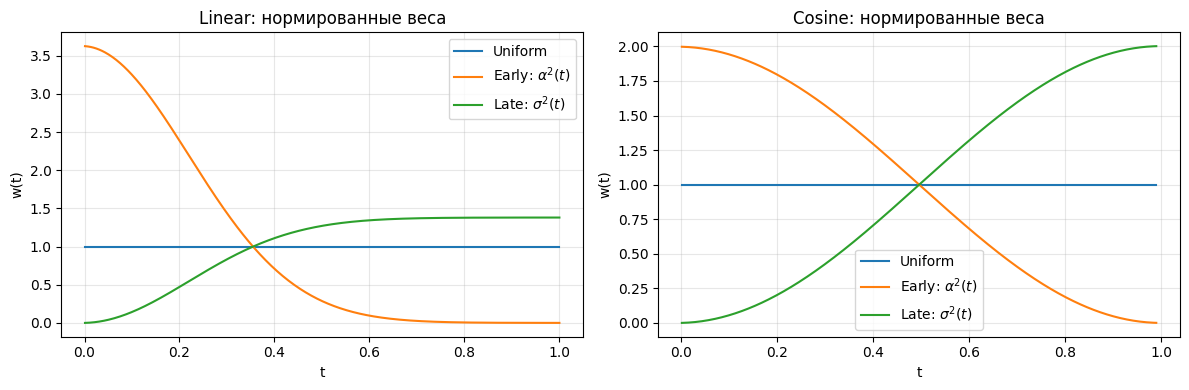

In [7]:
WEIGHT_LABELS = {
    'uniform': 'Uniform',
    'early': r'Early: $\alpha^2(t)$',
    'late': r'Late: $\sigma^2(t)$',
}


def time_weights(alpha, sigma, mode):
    if mode == 'uniform':
        weights = torch.ones_like(alpha)
    elif mode == 'early':
        weights = alpha.square()
    elif mode == 'late':
        weights = sigma.square()
    else:
        raise ValueError(f'Unknown weighting: {mode}')
    return weights / weights.mean().detach().clamp_min(1e-8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (schedule_name, schedule) in zip(axes, schedules.items()):
    t = torch.linspace(config.eps, schedule.t_max, 500).unsqueeze(1)
    alpha, sigma = schedule.alpha_sigma(t)
    for mode in WEIGHT_LABELS:
        weights = time_weights(alpha, sigma, mode)
        axis.plot(t, weights, label=WEIGHT_LABELS[mode])
    axis.set(title=f'{schedule_name}: нормированные веса', xlabel='t', ylabel='w(t)')
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 7. Обучение и reverse VP-SDE sampler

In [8]:
class VPTrainer:
    def __init__(self, config, schedule, weighting, data):
        self.config = config
        self.schedule = schedule
        self.weighting = weighting
        self.device = torch.device(config.device)

        tensor_data = torch.as_tensor(data, dtype=torch.float32)
        generator = torch.Generator().manual_seed(config.seed)
        self.dataloader = DataLoader(
            TensorDataset(tensor_data),
            batch_size=config.batch_size,
            shuffle=True,
            generator=generator,
        )

        self.model = ScoreModel(config).to(self.device)
        self.ema_model = ScoreModel(config).to(self.device)
        self.ema_model.load_state_dict(self.model.state_dict())
        self.ema_model.requires_grad_(False)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate)
        self.history = []

    @torch.no_grad()
    def _update_ema(self):
        decay = self.config.ema_decay
        for ema_parameter, parameter in zip(
            self.ema_model.parameters(), self.model.parameters()
        ):
            ema_parameter.mul_(decay).add_(parameter, alpha=1 - decay)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        total_samples = 0

        for (x_0,) in self.dataloader:
            x_0 = x_0.to(self.device)
            batch_size = x_0.size(0)
            t = torch.rand(batch_size, 1, device=self.device)
            t = self.config.eps + t * (self.schedule.t_max - self.config.eps)

            alpha, sigma = self.schedule.alpha_sigma(t)
            noise = torch.randn_like(x_0)
            x_t = alpha * x_0 + sigma * noise

            predicted_noise = self.model(x_t, t)
            per_sample_loss = (predicted_noise - noise).square().mean(dim=1)
            weights = time_weights(alpha, sigma, self.weighting).squeeze(1)
            loss = (weights * per_sample_loss).mean()

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            self.optimizer.step()
            self._update_ema()

            total_loss += loss.item() * batch_size
            total_samples += batch_size

        return total_loss / total_samples

    def run(self):
        label = f'{self.schedule.name} / {self.weighting}'
        print(f'{label}: device={self.device}, epochs={self.config.epochs}')
        for epoch in range(1, self.config.epochs + 1):
            loss = self.train_epoch()
            self.history.append(loss)
            if epoch == 1 or epoch % 200 == 0:
                print(f'  epoch {epoch:4d}: loss={loss:.5f}')
        return self.history


@torch.inference_mode()
def sample_reverse_vp_sde(model, schedule, config, num_samples=None):
    device = next(model.parameters()).device
    model.eval()
    num_samples = num_samples or config.sample_count
    seed_everything(config.sample_seed)

    # VP-SDE prior at T is approximately N(0, I).
    x = torch.randn(num_samples, 2, device=device)
    times = torch.linspace(
        schedule.t_max,
        config.eps,
        config.sampling_steps + 1,
        device=device,
    )

    for index in range(config.sampling_steps):
        t_value = times[index]
        next_t = times[index + 1]
        dt = t_value - next_t  # positive step while physical time decreases
        t = torch.full((num_samples, 1), t_value, device=device)

        beta = schedule.beta(t)
        _, sigma = schedule.alpha_sigma(t)
        predicted_noise = model(x, t)
        score = -predicted_noise / sigma.clamp_min(1e-5)

        forward_drift = -0.5 * beta * x
        reverse_drift = forward_drift - beta * score
        if index < config.sampling_steps - 1:
            brownian_noise = torch.randn_like(x)
        else:
            brownian_noise = torch.zeros_like(x)

        x = (
            x
            - reverse_drift * dt
            + torch.sqrt(beta * dt) * brownian_noise
        )

    # One final conditional-mean denoising step at epsilon.
    t = torch.full((num_samples, 1), config.eps, device=device)
    alpha, sigma = schedule.alpha_sigma(t)
    x = (x - sigma * model(x, t)) / alpha.clamp_min(1e-5)
    return x.cpu().numpy()


def symmetric_chamfer_distance(generated, target):
    target_neighbors = NearestNeighbors(n_neighbors=1).fit(target)
    generated_to_target = target_neighbors.kneighbors(generated, return_distance=True)[0][:, 0]
    generated_neighbors = NearestNeighbors(n_neighbors=1).fit(generated)
    target_to_generated = generated_neighbors.kneighbors(target, return_distance=True)[0][:, 0]
    return float(np.mean(generated_to_target ** 2) + np.mean(target_to_generated ** 2))

## 8. Эксперимент 2 × 3

Каждая комбинация обучается с нуля с одинаковым seed. Для генерации используется EMA модели и один seed для начального Gaussian noise/Brownian noise. Это уменьшает случайность попарного сравнения.

In [9]:
experiment_results = []
histories = {}
generated_samples = {}

for schedule_name in ('Linear', 'Cosine'):
    for weighting in ('uniform', 'early', 'late'):
        seed_everything(config.seed)
        schedule = make_schedule(schedule_name, config)
        trainer = VPTrainer(config, schedule, weighting, star)
        history = trainer.run()
        samples = sample_reverse_vp_sde(trainer.ema_model, schedule, config)
        chamfer = symmetric_chamfer_distance(samples, star)

        key = (schedule_name, weighting)
        histories[key] = history
        generated_samples[key] = samples
        experiment_results.append({
            'schedule': schedule_name,
            'weighting': weighting,
            'final_loss': history[-1],
            'mean_last_100_loss': float(np.mean(history[-100:])),
            'chamfer': chamfer,
        })
        print(f'  symmetric Chamfer={chamfer:.6f}\n')

        trainer.model.to('cpu')
        trainer.ema_model.to('cpu')
        del trainer
        clear_device_cache()

results_df = pd.DataFrame(experiment_results).sort_values('chamfer').reset_index(drop=True)
results_df.style.format({
    'final_loss': '{:.5f}',
    'mean_last_100_loss': '{:.5f}',
    'chamfer': '{:.6f}',
})

Linear / uniform: device=mps, epochs=1200


  epoch    1: loss=0.92707


  epoch  200: loss=0.16872


  epoch  400: loss=0.17118


  epoch  600: loss=0.18062


...

  epoch  800: loss=0.11410


  epoch 1000: loss=0.11497


  epoch 1200: loss=0.11332


  symmetric Chamfer=0.050798



,schedule,weighting,final_loss,mean_last_100_loss,chamfer
0,Cosine,early,0.44009,0.45364,0.001736
1,Linear,early,0.42802,0.42747,0.003411
2,Cosine,uniform,0.27931,0.28591,0.003744
3,Linear,uniform,0.15234,0.15382,0.007196
4,Linear,late,0.04697,0.04733,0.046451
5,Cosine,late,0.11332,0.11346,0.050798


## 9. Графики сравнения

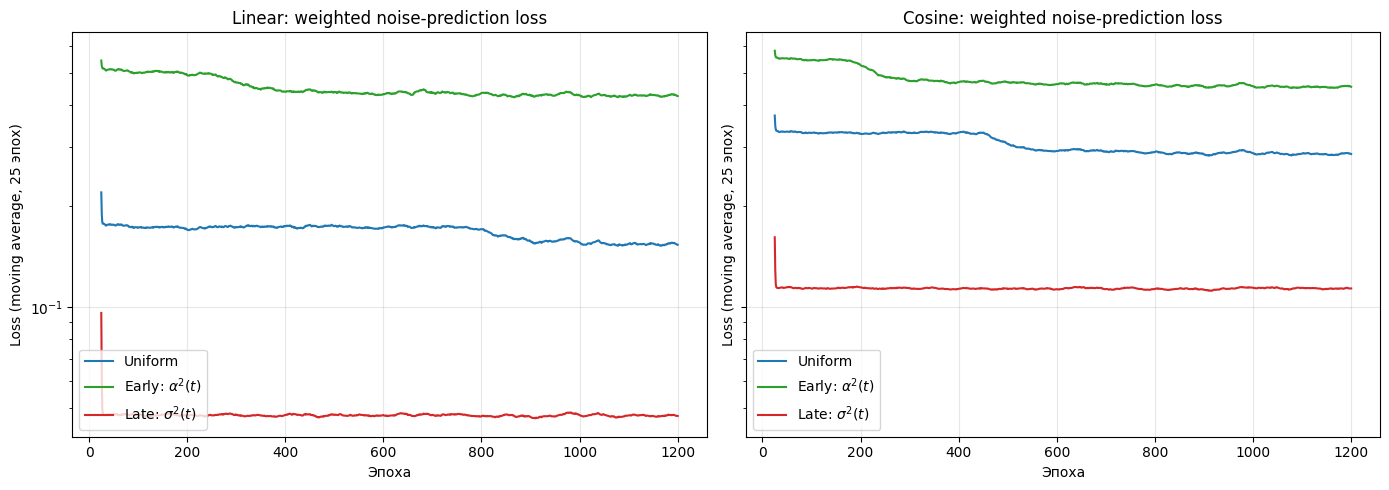

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {'uniform': 'tab:blue', 'early': 'tab:green', 'late': 'tab:red'}

for axis, schedule_name in zip(axes, ('Linear', 'Cosine')):
    for weighting in ('uniform', 'early', 'late'):
        history = histories[(schedule_name, weighting)]
        window = 25
        smoothed = np.convolve(history, np.ones(window) / window, mode='valid')
        axis.plot(
            np.arange(window, len(history) + 1),
            smoothed,
            color=colors[weighting],
            label=WEIGHT_LABELS[weighting],
        )
    axis.set(
        title=f'{schedule_name}: weighted noise-prediction loss',
        xlabel='Эпоха',
        ylabel='Loss (moving average, 25 эпох)',
        yscale='log',
    )
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
display(fig)
plt.close(fig)

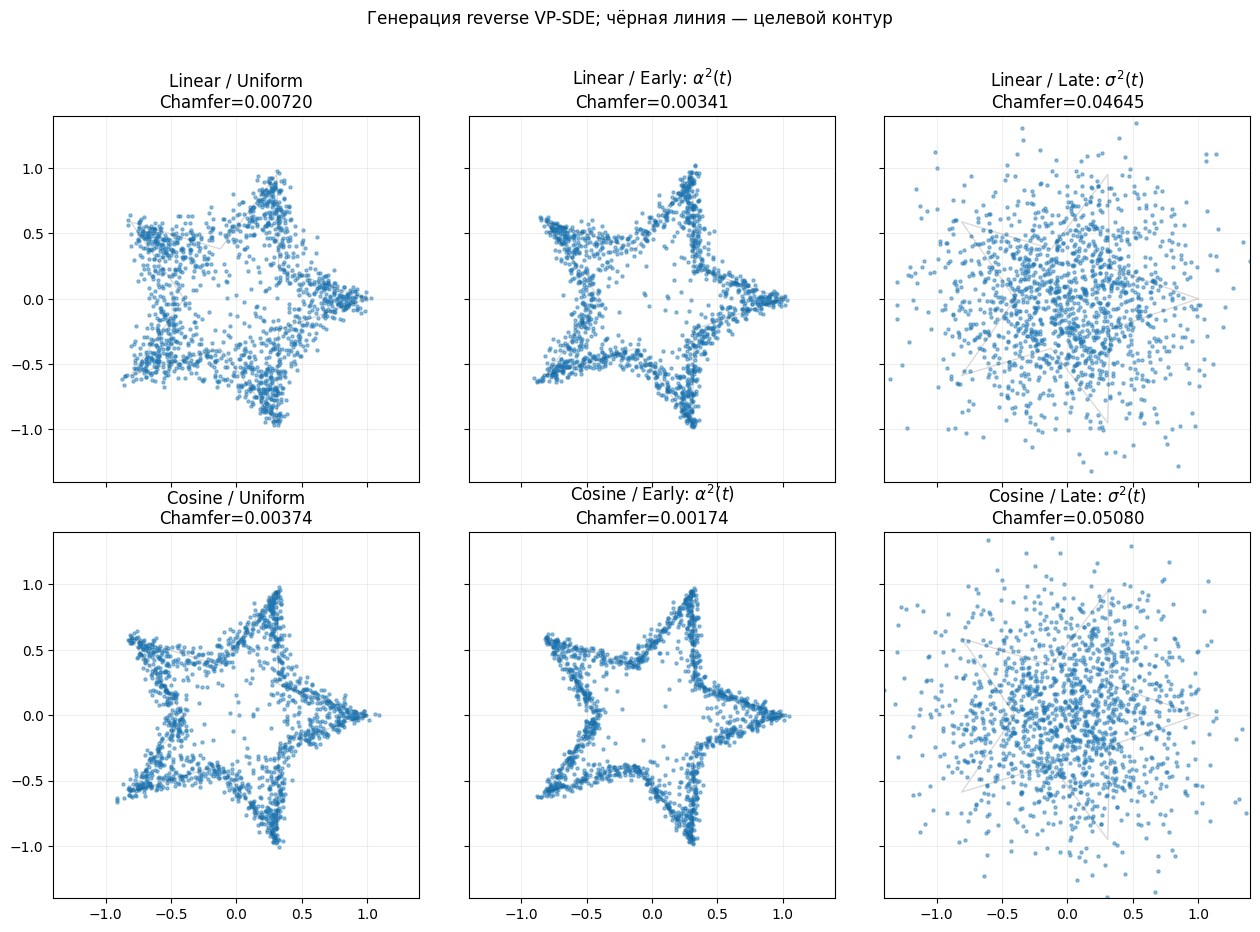

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9), sharex=True, sharey=True)

for row, schedule_name in enumerate(('Linear', 'Cosine')):
    for column, weighting in enumerate(('uniform', 'early', 'late')):
        axis = axes[row, column]
        samples = generated_samples[(schedule_name, weighting)]
        chamfer = results_df.loc[
            (results_df['schedule'] == schedule_name)
            & (results_df['weighting'] == weighting),
            'chamfer',
        ].iloc[0]
        axis.plot(star[:, 0], star[:, 1], color='black', alpha=0.15, linewidth=1)
        axis.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.45)
        axis.set_title(
            f'{schedule_name} / {WEIGHT_LABELS[weighting]}\nChamfer={chamfer:.5f}'
        )
        axis.set_xlim(-1.4, 1.4)
        axis.set_ylim(-1.4, 1.4)
        axis.set_aspect('equal')
        axis.grid(alpha=0.2)

plt.suptitle('Генерация reverse VP-SDE; чёрная линия — целевой контур', y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

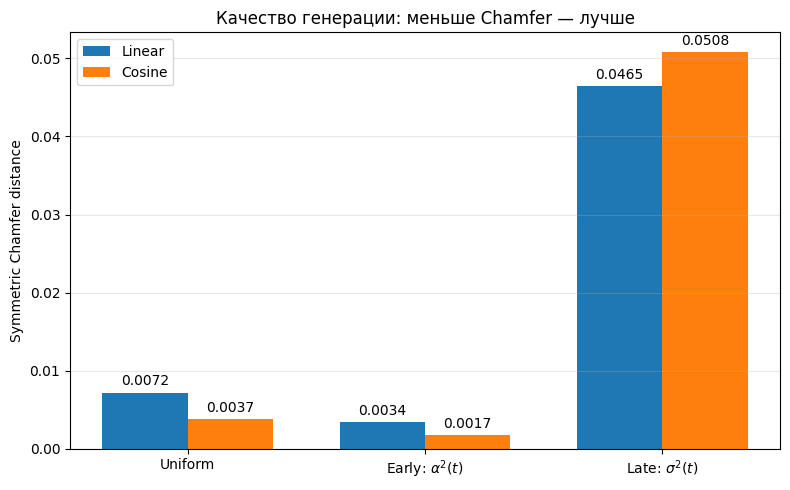

,schedule,weighting,final_loss,mean_last_100_loss,chamfer
0,Cosine,early,0.44009,0.45364,0.001736
1,Linear,early,0.42802,0.42747,0.003411
2,Cosine,uniform,0.27931,0.28591,0.003744
3,Linear,uniform,0.15234,0.15382,0.007196
4,Linear,late,0.04697,0.04733,0.046451
5,Cosine,late,0.11332,0.11346,0.050798


In [12]:
pivot = results_df.pivot(index='weighting', columns='schedule', values='chamfer')
pivot = pivot.reindex(['uniform', 'early', 'late'])[['Linear', 'Cosine']]

fig, axis = plt.subplots(figsize=(8, 5))
positions = np.arange(len(pivot.index))
width = 0.36
for offset, schedule_name in [(-width / 2, 'Linear'), (width / 2, 'Cosine')]:
    bars = axis.bar(
        positions + offset,
        pivot[schedule_name].values,
        width,
        label=schedule_name,
    )
    axis.bar_label(bars, fmt='%.4f', padding=3)

axis.set_xticks(positions, [WEIGHT_LABELS[index] for index in pivot.index])
axis.set(title='Качество генерации: меньше Chamfer — лучше', ylabel='Symmetric Chamfer distance')
axis.grid(axis='y', alpha=0.3)
axis.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

display(results_df.style.format({
    'final_loss': '{:.5f}',
    'mean_last_100_loss': '{:.5f}',
    'chamfer': '{:.6f}',
}))

## 10. Выводы

1. **Лучший time weighting — $w(t)=\alpha^2(t)$.** Для linear schedule Chamfer снизился с **0.007196** (`uniform`) до **0.003411** (`early`), то есть на 52.6%. Для cosine — с **0.003744** до **0.001736**, на 53.6%. На графиках этот вариант даёт наиболее тонкие лучи и лучше сохраняет внутренние углы звезды. Причина: больший градиент получают состояния с малым уровнем шума, где модель учит точную геометрию одномерного контура.

2. **$w(t)=\sigma^2(t)$ оказался худшим.** Linear/late получил Chamfer **0.046451**, cosine/late — **0.050798**; визуально оба варианта дают почти Gaussian cloud вместо звезды. Такое weighting концентрирует обучение на больших $t$, где восстановление грубой структуры из сильного шума важно, но почти не обучает финальное уточнение контура при малом $t$.

3. **Низкий weighted loss не означает хорошую генерацию.** У `late` loss численно ниже, чем у остальных вариантов, однако samples хуже на порядок. Разные веса меняют сам objective и сложность учитываемых времён, поэтому loss допустимо сравнивать как динамику внутри одного weighting, но не использовать как единственный критерий между weighting. Нужны samples и геометрическая метрика.

4. **Cosine лучше linear при разумном weighting.** При `uniform` cosine уменьшил Chamfer с 0.007196 до **0.003744**; при $\alpha^2(t)$ — с 0.003411 до **0.001736**. Cosine медленнее уничтожает сигнал в начале и середине процесса, поэтому модель видит больше промежуточных состояний с различимой геометрией. При плохом `late` weighting преимущество исчезает: расписание не компенсирует отсутствие внимания к малым $t$.

5. **Итог для этой задачи:** использовать **cosine VP-SDE + $\alpha^2(t)$ weighting**. Вывод относится к контуру звезды, одной архитектуре и одному seed; для статистически строгого сравнения нужны повторные запуски с несколькими seed. Тем не менее визуальные результаты и symmetric Chamfer согласованно выбирают одну конфигурацию.